# Week 5 — Optimization: linear, integer, and nonlinear

Companion notebook of the fifth lecture. Weeks 2–4 built, fitted, and simulated models; this week makes a model **choose**: find the decision variables that optimize an objective under constraints. Linear programming solved by **solvers** (`scipy.optimize` — no tableau, no hand pivoting), **shadow prices** (the same number a Lagrange multiplier gives), integer programming, and nonlinear optimization with `minimize`. The case is the **2022 MCM B** water-sharing problem: a linear program that allocates Colorado River water between two dams and seven states.

**How to run**: Anaconda locally (`jupyter lab`), or Colab/Binder from the [course repository](https://github.com/liwt31/MathModel). Run cells in order with `Shift+Enter`.

**Note.** The exercises here and on the slides are **practice for yourself** — they are **not** the graded assignments. Problem sets are released separately on Blackboard, with due dates.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
try:                                  # optional style file, ships with the course
    plt.style.use("mm.mplstyle")
except OSError:
    pass
from scipy.optimize import linprog, milp, minimize, LinearConstraint, Bounds

## 1. Linear programming: the carpenter

A decision problem has three parts: **decision variables** (what we choose), an **objective** (what we optimize), and **constraints** (what limits the choice). The carpenter makes tables ($x_1$, profit \$25) and bookcases ($x_2$, profit \$30) from 690 units of wood and 120 units of labor; a table needs 20 wood and 5 labor, a bookcase 30 wood and 4 labor:

$$\max\ 25x_1 + 30x_2 \quad \text{s.t.}\ 20x_1 + 30x_2 \le 690,\quad 5x_1 + 4x_2 \le 120,\quad x_1, x_2 \ge 0.$$

Objective and constraints are **linear** in the decision variables — that is what makes it a linear program, and what lets a solver guarantee the global optimum.

In [2]:
c = [-25, -30]                             # linprog MINIMIZES; maximize profit = minimize -profit
A_ub = [[20, 30], [5, 4]]
b_ub = [690, 120]
res = linprog(c, A_ub=A_ub, b_ub=b_ub, method="highs")
print(f"optimum: x = {res.x},  profit = {-res.fun:.0f}")

optimum: x = [12. 15.],  profit = 750


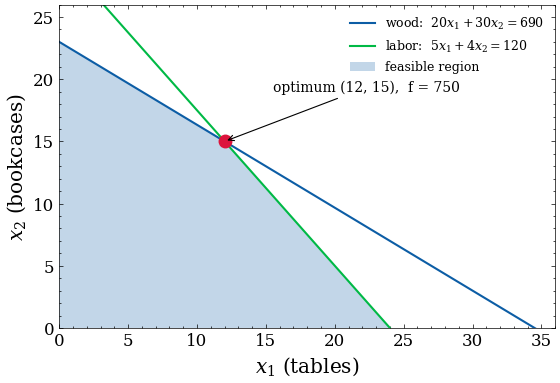

In [3]:
x1 = np.linspace(0, 40, 400)
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.plot(x1, (690 - 20 * x1) / 30, label="wood:  $20x_1+30x_2=690$")
ax.plot(x1, (120 - 5 * x1) / 4, label="labor:  $5x_1+4x_2=120$")
ax.fill_between(x1, 0, np.minimum((690 - 20 * x1) / 30, (120 - 5 * x1) / 4), where=(x1 <= 24),
                alpha=0.25, label="feasible region")
ax.plot(12, 15, "o", color="crimson", ms=9)
ax.annotate("optimum (12, 15),  f = 750", (12, 15), xytext=(15.5, 19),
            arrowprops=dict(arrowstyle="->", lw=0.8))
ax.set_xlim(0, 36); ax.set_ylim(0, 26)
ax.set_xlabel("$x_1$ (tables)"); ax.set_ylabel("$x_2$ (bookcases)")
ax.legend(frameon=False, fontsize=9)
plt.show()

The shaded region is the **feasible region**. Two facts make linear programming tractable: the region is a **convex set** (the segment between any two feasible points stays feasible), and the optimum of a linear objective sits at a **corner point** of that region.

## 2. Corner points, by hand once

The classic recipe: intersect every pair of constraint lines, keep the feasible intersections, evaluate the objective at each. We run it once on the carpenter — and then never again, because the solver does it better.

In [4]:
from itertools import combinations

lines = [((20, 30), 690), ((5, 4), 120), ((1, 0), 0), ((0, 1), 0)]   # constraints + the two axes

def intersect(l1, l2):
    A = np.array([l1[0], l2[0]], dtype=float)
    if abs(np.linalg.det(A)) < 1e-9:
        return None
    return np.linalg.solve(A, np.array([l1[1], l2[1]], dtype=float))

points = [p for l1, l2 in combinations(lines, 2) if (p := intersect(l1, l2)) is not None]
feasible = [p for p in points
            if 20 * p[0] + 30 * p[1] <= 690 + 1e-9 and 5 * p[0] + 4 * p[1] <= 120 + 1e-9
            and p[0] >= -1e-9 and p[1] >= -1e-9]
vals = [(25 * p[0] + 30 * p[1], p) for p in feasible]
for v, p in sorted(vals, reverse=True):
    print(f"corner {np.round(p, 2)}  ->  profit = {v:.2f}")
print("best corner:", np.round(max(vals)[1], 2))

corner [12. 15.]  ->  profit = 750.00
corner [ 0. 23.]  ->  profit = 690.00
corner [24.  0.]  ->  profit = 600.00
corner [0. 0.]  ->  profit = 0.00
best corner: [12. 15.]


## 3. A fitting problem in LP clothes: the Chebyshev criterion

Week 3's Chebyshev criterion (minimize the largest deviation) looked different from least squares — but it is a linear program in disguise. Fit $y = cx$ to three points by introducing $r = \max_i |y_i - c x_i|$ and requiring $r \ge y_i - c x_i$ and $r \ge -(y_i - c x_i)$; minimize $r$. The absolute values become plain linear constraints.

Chebyshev fit: y = 2.500 x,   max deviation r = 0.500


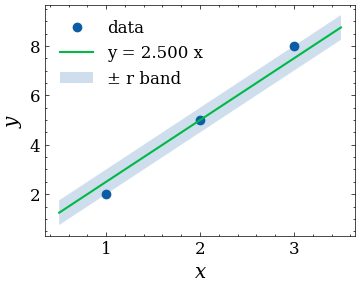

In [5]:
data = [(1, 2), (2, 5), (3, 8)]
c = [0, 1]                                       # minimize r  (c has zero objective cost)
A_ub, b_ub = [], []
for xi, yi in data:
    A_ub += [[xi, -1], [-xi, -1]]                #  c*xi - r <= yi   and   -c*xi - r <= -yi
    b_ub += [yi, -yi]
res = linprog(c, A_ub=np.array(A_ub), b_ub=np.array(b_ub), method="highs")
print(f"Chebyshev fit: y = {res.x[0]:.3f} x,   max deviation r = {res.x[1]:.3f}")

xs = np.linspace(0.5, 3.5, 100)
plt.plot([p[0] for p in data], [p[1] for p in data], "o", label="data")
plt.plot(xs, res.x[0] * xs, label=f"y = {res.x[0]:.3f} x")
plt.fill_between(xs, res.x[0] * xs - res.x[1], res.x[0] * xs + res.x[1], alpha=0.2, label="± r band")
plt.xlabel("$x$"); plt.ylabel("$y$"); plt.legend(frameon=False)
plt.show()

## 4. Shadow prices: what one more unit of wood is worth

Re-solve the carpenter with **one more unit of wood** and watch the optimal profit move. The rate of change of the optimum with respect to a constraint's right-hand side is the **shadow price** of that resource — and `linprog` reports it directly as the constraint **marginal**.

In [6]:
def profit(wood, labor):
    r = linprog([-25, -30], A_ub=[[20, 30], [5, 4]], b_ub=[wood, labor], method="highs")
    return -r.fun

print(f"profit(690, 120) = {profit(690, 120):.4f}")
print(f"profit(691, 120) = {profit(691, 120):.4f}   -> gain per unit wood  = {profit(691, 120) - profit(690, 120):.4f}")
print(f"profit(690, 121) = {profit(690, 121):.4f}   -> gain per unit labor = {profit(690, 121) - profit(690, 120):.4f}")

res = linprog([-25, -30], A_ub=[[20, 30], [5, 4]], b_ub=[690, 120], method="highs")
print("solver marginals (negated):", -res.ineqlin.marginals)

profit(690, 120) = 750.0000
profit(691, 120) = 750.7143   -> gain per unit wood  = 0.7143
profit(690, 121) = 752.1429   -> gain per unit labor = 2.1429
solver marginals (negated): [0.71428571 2.14285714]


## 4b. The shadow price, drawn

The notebook's exercise 2 asks where the price stops being valid; the full curve makes the answer visible. Re-solve the carpenter for a range of wood quantities and plot the optimal profit: a straight line with slope $0.714$ while labor binds, a kink at $900$ units of wood where wood stops binding, and a flat tail where extra wood prices at zero.

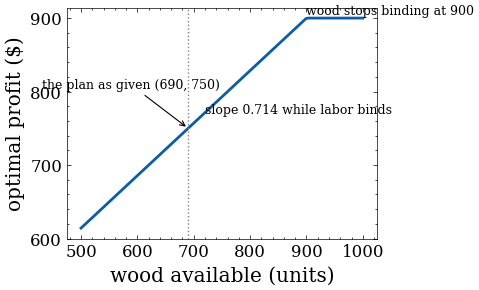

In [7]:
def profit_w(wood):
    r = linprog([-25, -30], A_ub=[[20, 30], [5, 4]], b_ub=[wood, 120], method="highs")
    return -r.fun

woods = np.linspace(500, 1000, 120)
profits = [profit_w(w) for w in woods]

plt.plot(woods, profits, lw=2)
plt.axvline(690, color="gray", ls=":", lw=1)
plt.annotate("the plan as given (690, 750)", (690, 750), xytext=(430, 805),
             arrowprops=dict(arrowstyle="->", lw=0.8), fontsize=9)
plt.annotate("slope 0.714 while labor binds", (720, 770), fontsize=9)
plt.annotate("wood stops binding at 900", (900, 905), fontsize=9)
plt.xlabel("wood available (units)"); plt.ylabel("optimal profit ($)")
plt.show()

The finite differences match the solver's marginals. The same number appears in **Lagrange multipliers**: at a constrained optimum, the multiplier $\lambda$ measures how fast the optimal value changes as the constraint is relaxed. Here the constraints bind, so the prices are positive.

## 5. Integer programming: when the answer must be whole

Tables and bookcases come in whole numbers. Rounding the LP answer happens to be feasible here, but rounding is not safe in general. `scipy.optimize.milp` adds **integrality** to the same linear program and solves it with branch-and-bound: it solves LP relaxations, splits the problem where a variable is fractional, and stops only when the best integer point is provably optimal.

In [8]:
c = np.array([-25.0, -30.0])
A_ub = np.array([[20.0, 30.0], [5.0, 4.0]])
b_ub = np.array([690.0, 120.0])
res = milp(c=c, constraints=[LinearConstraint(A_ub, -np.inf, b_ub)],
           integrality=[1, 1], bounds=Bounds([0, 0], [np.inf, np.inf]))
print(f"integer optimum: profit = {-res.fun:.2f} at x = {res.x}")
print(f"LP optimum was   profit = 750.00 at x = [12. 15.]  (rounding happened to work here)")

integer optimum: profit = 750.00 at x = [12. 15.]
LP optimum was   profit = 750.00 at x = [12. 15.]  (rounding happened to work here)


## 6. Nonlinear optimization: the computer factory

Nonlinear objectives no longer have corner points. The classics apply instead: find critical points where the **gradient** vanishes, then check the **Hessian**. A factory sells two computer models; competition lowers prices as volume grows, and the profit becomes

$$P(x_1,x_2) = 1440\,x_1 - 0.1x_1^2 + 1740\,x_2 - 0.1x_2^2 - 0.07x_1x_2 - 400000.$$

Setting both partial derivatives to zero gives $x_1 = 4736$, $x_2 = 7043$ by hand. The Hessian is constant here, $H = \begin{pmatrix} -0.2 & -0.07\\ -0.07 & -0.2\end{pmatrix}$, with eigenvalues $-0.13$ and $-0.27$ — both negative, so the critical point is a maximum.

In [9]:
def neg_profit(x):
    x1, x2 = x
    return -(1440 * x1 - 0.1 * x1**2 + 1740 * x2 - 0.1 * x2**2 - 0.07 * x1 * x2 - 400000)

def grad(x):
    x1, x2 = x
    return np.array([-(1440 - 0.2 * x1 - 0.07 * x2), -(1740 - 0.07 * x1 - 0.2 * x2)])

res = minimize(neg_profit, x0=[0, 0], jac=grad, method="BFGS")
H = np.array([[-0.2, -0.07], [-0.07, -0.2]])
print(f"scipy optimum: x = ({res.x[0]:.1f}, {res.x[1]:.1f}),  profit = {-res.fun:,.0f}")
print(f"Hessian eigenvalues: {np.linalg.eigvalsh(H)}  (both negative -> maximum)")
print(f"profit at the hand-computed point (4736, 7043): {-neg_profit([4736, 7043]):,.0f}")

scipy optimum: x = (4735.0, 7042.7),  profit = 9,136,410
Hessian eigenvalues: [-0.27 -0.13]  (both negative -> maximum)
profit at the hand-computed point (4736, 7043): 9,136,410


## 7. Gradient descent and local minima: a trap you can fall into

Fit $y = a\cos(bx)$ to five points by least squares (Week 3's nonlinear fitting). The objective is nonlinear in $b$, so **gradient descent can get stuck**: from the start $a_0 = b_0 = 0$ the gradient in $b$ is exactly zero and the fit collapses to a constant; from the data-informed start $a_0 = 1.5$, $b_0 = 3$ it finds the global minimum. The **choice of starting point** is part of the method.

start (0, 0):    a = 0.403, b = -0.672,  S = 6.0741   <- trapped
start (1.5, 3):  a = 1.511, b = 2.701,  S = 0.0006   <- global


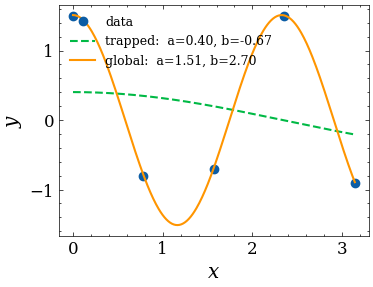

In [10]:
xs = np.array([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ys = np.array([1.5, -0.8, -0.7, 1.5, -0.9])

def S(ab):
    a, b = ab
    return np.sum((ys - a * np.cos(b * xs))**2)

bad  = minimize(S, x0=[0.0, 0.0], method="Nelder-Mead")
good = minimize(S, x0=[1.5, 3.0], method="Nelder-Mead")
print(f"start (0, 0):    a = {bad.x[0]:.3f}, b = {bad.x[1]:.3f},  S = {bad.fun:.4f}   <- trapped")
print(f"start (1.5, 3):  a = {good.x[0]:.3f}, b = {good.x[1]:.3f},  S = {good.fun:.4f}   <- global")

cs = np.linspace(0, np.pi, 300)
plt.plot(xs, ys, "o", label="data")
plt.plot(cs, bad.x[0] * np.cos(bad.x[1] * cs), "--", label=f"trapped:  a={bad.x[0]:.2f}, b={bad.x[1]:.2f}")
plt.plot(cs, good.x[0] * np.cos(good.x[1] * cs), label=f"global:  a={good.x[0]:.2f}, b={good.x[1]:.2f}")
plt.xlabel("$x$"); plt.ylabel("$y$"); plt.legend(frameon=False, fontsize=9)
plt.show()

## 8. Constrained nonlinear optimization: Lagrange, KKT, and `minimize`

With an **equality** constraint, the Lagrange multiplier method turns the constrained problem into the unconstrained problem $L(x, \lambda) = f(x) + \lambda\,g(x)$: at the optimum, $\nabla_x L = 0$ and $g = 0$. With **inequality** constraints the same machinery gains the **KKT conditions** (the multiplier is nonnegative, and the constraint is either tight or its multiplier is zero). The consumer problem makes it concrete: maximize utility $u = x_1 x_2$ subject to the budget $p_1 x_1 + p_2 x_2 = I$. By hand, $x_1 = I/(2p_1)$, $x_2 = I/(2p_2)$, and the multiplier $\lambda = I/(2p_1 p_2)$ is the marginal utility of money — a shadow price again.

In [11]:
p1, p2, I = 2.0, 1.0, 100.0
res = minimize(lambda v: -(v[0] * v[1]), x0=[10, 10],
               constraints=[{"type": "eq", "fun": lambda v: p1 * v[0] + p2 * v[1] - I}],
               bounds=[(0, None), (0, None)], method="SLSQP")
print(f"SLSQP:  x = ({res.x[0]:.2f}, {res.x[1]:.2f}),  utility = {res.x[0] * res.x[1]:.2f}")
print(f"by hand (Lagrange): x = (I/2p1, I/2p2) = ({I/(2*p1):.2f}, {I/(2*p2):.2f}),  lambda = {I/(2*p1*p2):.4f}")

SLSQP:  x = (25.00, 50.00),  utility = 1250.00
by hand (Lagrange): x = (I/2p1, I/2p2) = (25.00, 50.00),  lambda = 25.0000


## 9. Case study: sharing the Colorado River (2022 MCM B)

The **2022 MCM Problem B** allocates water from two Colorado River dams — Glen Canyon (Lake Powell) and Hoover (Lake Mead) — to seven states (CA, AZ, NM, CO, WY, UT, NV) plus Mexico, under drought. Team **2228168** (Outstanding) formulates Problem 1 as a **transportation linear program**: water is shipped from two reservoirs to seven states, and the total transport cost is minimized.

In [12]:
states = ["CA", "AZ", "NM", "CO", "WY", "UT", "NV"]
demand_maf = np.array([4.400, 2.800, 0.844, 3.881, 1.050, 1.725, 0.300])   # their Table 1 (MAF/year)
D = demand_maf * 1e6 / 12                                                  # acre-feet per month
d_p = np.array([562.756, 225.368, 429.163, 448.691, 613.939, 210.327, 320.672])  # Glen Canyon -> state (mi)
d_m = np.array([353.238, 257.871, 612.090, 686.919, 802.099, 358.346, 320.672])  # Hoover -> state (mi)
q_max = np.array([160218.0, 253627.0])                                     # max discharge (acre-ft/month)
print("monthly demand per state (acre-ft):", np.round(D).astype(int))
print(f"total draw per month: {D.sum():,.0f}  + Mexico 125,000")

monthly demand per state (acre-ft): [366667 233333  70333 323417  87500 143750  25000]
total draw per month: 1,250,000  + Mexico 125,000


Their Equation (13) is the whole model: decision variables $x_{p,i}, x_{m,i}$ (water from Powell/Mead to state $i$) plus the two releases, $q_m$ (Glen Canyon into Lake Mead, the paper's notation) and $q_M$ (Hoover towards Mexico); objective $\min \sum_i (d_{p,i} x_{p,i} + d_{m,i} x_{m,i})$; constraints: every state's demand is met exactly, Mexico's 1.5 MAF/year flows from Hoover, reservoir levels stay between dead-pool and full pool (via storage curves they linearized, $R^2 = 0.9925$), Powell's discharge feeds Mead, and each dam's discharge respects its power-generation maximum. The paper does not print the lake surface areas, the January 2021 levels, or the inflows, so this rebuild omits the two level rows; in January they are slack (both lakes hold far more than one month's draws), and the program below keeps the demand rows and the two release limits.

In [13]:
n = len(states)
c = np.concatenate([d_p, d_m, [0.0, 0.0]])        # transport cost; discharges are free
A_eq = np.zeros((n, 2 * n + 2)); b_eq = np.zeros(n)
for i in range(n):                                # x_{p,i} + x_{m,i} = D_i
    A_eq[i, i] = A_eq[i, n + i] = 1.0; b_eq[i] = D[i]
bounds = [(0, None)] * (2 * n) + [(0.0, q_max[0]), (125000.0, q_max[1])]   # q_p turbine cap; q_m >= Mexico
res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")
xp, xm = res.x[:n], res.x[n:2 * n]
qp, qm = res.x[2 * n], res.x[2 * n + 1]           # turbine flows (Mexico rides on Hoover)
print(f"{'state':6s}{'Powell':>12s}{'Hoover':>12s}")
for i, s in enumerate(states):
    print(f"{s:6s}{xp[i]:12,.0f}{xm[i]:12,.0f}")
print(f"Powell total = {xp.sum():,.0f}   Hoover total = {xm.sum():,.0f}   (paper: 858,333 / 391,667)")
print(f"turbine flows: Powell {qp:,.0f} <= 160,218,  Hoover {qm:,.0f} <= 253,627 (covers Mexico)")

state       Powell      Hoover
CA               0     366,667
AZ         233,333           0
NM          70,333           0
CO         323,417           0
WY          87,500           0
UT         143,750           0
NV               0      25,000
Powell total = 858,333   Hoover total = 391,667   (paper: 858,333 / 391,667)
turbine flows: Powell 0 <= 160,218,  Hoover 125,000 <= 253,627 (covers Mexico)


The solver reproduces the paper's Table 4: each state is served by the **nearer dam** (AZ, NM, CO, WY, UT from Powell; CA and NV from Hoover; NV sits equidistant and goes to Hoover), and Hoover's discharge covers Mexico's 125,000 acre-feet per month.

In [14]:
print("shadow prices on the demand rows (miles per extra acre-ft delivered):")
for i, s in enumerate(states):
    print(f"  {s:6s} {res.eqlin.marginals[i]:10.3f}")
print(f"Mexico row price: {-res.eqlin.marginals[-1]:.3f}" if res.eqlin.marginals.size > n else "")

shadow prices on the demand rows (miles per extra acre-ft delivered):
  CA        353.238
  AZ        225.368
  NM        429.163
  CO        448.691
  WY        613.939
  UT        210.327
  NV        320.672



The **shadow price** of a state's demand row is the marginal transport cost of one more acre-foot there, reported by the solver as the row's marginal. The objective is distance times volume (the paper drops the cost per mile), so the prices are in miles: each equals the distance from the state's serving dam. These shadow prices are our computation; the paper minimizes cost and reports the allocation, and the prices come free with the same solve.

In [15]:
drain = 1106074.571                       # their eq. 14: net monthly draw of the system (acre-ft)
V_end = 54199.52                          # their remaining storage at month 24 (both lakes)
V0 = 23 * drain + V_end                   # initial usable storage implied by their own numbers
V = V0
months = 0
while V >= 0:
    months += 1
    V -= drain
print(f"initial usable storage (derived): {V0:,.0f} acre-ft")
print(f"feasible months = {months - 1}   (paper: 23)")
print(f"month-{months} shortfall = {-V:,.0f} acre-ft   (paper: 1,051,875)")
print(f"gross extra water if inflow stops: {1375000 - V_end:,.0f}   (paper: 1,320,800)")

initial usable storage (derived): 25,493,915 acre-ft
feasible months = 23   (paper: 23)
month-24 shortfall = 1,051,875 acre-ft   (paper: 1,051,875)
gross extra water if inflow stops: 1,320,800   (paper: 1,320,800)


The paper does not print the starting storage, so this loop starts from the storage its own numbers imply ($23 \times 1{,}106{,}075 + 54{,}200 \approx 25.5$ million acre-feet). The 23 months therefore check the arithmetic of the paper's drain rate and end state; they are not an independent reproduction from storage data. The two "extra water" numbers answer different questions: $1{,}106{,}075 - 54{,}200 = 1{,}051{,}875$ if the river keeps flowing (their summary), and $1{,}375{,}000 - 54{,}200 = 1{,}320{,}800$ if no river water arrives (their §4.3).

## Practice exercises

**These are practice for yourself — they are not the graded assignments.** Problem sets are released separately on Blackboard, with due dates.

1. **Carpenter, by solver.** Add a third product (chairs, profit \$35, 15 wood, 3 labor) to the carpenter's LP and re-solve with `linprog`. Which corner point wins now, and what are the new shadow prices of wood and labor?
2. **Verify a price by hand.** For the carpenter, raise labor to 121 and re-solve. Does the profit rise by exactly the solver's labor marginal? Up to what labor level does that marginal stay valid (re-solve for a range of labor values and plot the profit)?
3. **Chebyshev vs least squares.** Fit $y = ax + b$ to $x = 0, 1, 2, 3$, $y = 1.9, 2.9, 3.6, 4.6$ by the Chebyshev LP (variables $a, b, r$) and by least squares. Which point does each criterion favor?
4. **Integer carpenter.** Change the profits to \$26 and \$29 and compare the LP optimum with the `milp` integer optimum. Find a profit pair where rounding the LP answer is infeasible.
5. **Trap check.** In the $a\cos(bx)$ fit, try three more starting points of your own. Which ones get trapped, and can you predict it from the shape of $S(a, b)$ before running?
6. **River prices.** In the case LP, raise Arizona's demand by 10\% and re-solve. Does Arizona's shadow price rise or fall, and which dam serves the extra water?
